<a href="https://colab.research.google.com/github/bz2562-cmd/streamflow-wq-lstm/blob/main/%5BSB%5D_KFPlots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[link text](https://)1:1 Ratio Set 3 KF



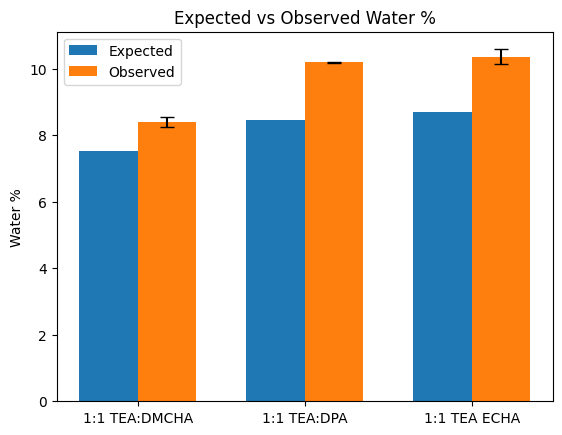

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data
data = {
    "Pure DMCHA": [10.31, 9.99],
    "Pure TEA": [4.95, 4.86],
    "Pure DPA": [12.07, 11.97],
    "Pure ECHA": [12.60, 12.34],
    "1:1 TEA:DMCHA": [8.5400, 8.2400],
    "1:1 TEA:DPA": [10.2100, 10.1600],
    "1:1 TEA ECHA": [10.5800, 10.1400],
}

# Means and ranges
means = {k: np.mean(v) for k, v in data.items()}
mins = {k: np.min(v) for k, v in data.items()}
maxs = {k: np.max(v) for k, v in data.items()}

# Expected values (average of pure components)
expected = {
    "1:1 TEA:DMCHA": (means["Pure TEA"] + means["Pure DMCHA"]) / 2,
    "1:1 TEA:DPA": (means["Pure TEA"] + means["Pure DPA"]) / 2,
    "1:1 TEA ECHA": (means["Pure TEA"] + means["Pure ECHA"]) / 2,
}

labels = list(expected.keys())
x = np.arange(len(labels))

observed_means = [means[l] for l in labels]
expected_means = [expected[l] for l in labels]

# Error bars (range)
observed_err = [
    [means[l] - mins[l] for l in labels],  # lower
    [maxs[l] - means[l] for l in labels],  # upper
]

# Plot
width = 0.35
plt.figure()

plt.bar(x - width/2, expected_means, width, label="Expected")
plt.bar(x + width/2, observed_means, width, yerr=observed_err, capsize=5, label="Observed")

plt.xticks(x, labels)
plt.ylabel("Water %")
plt.title("Expected vs Observed Water %")
plt.legend()

plt.show()


Linearity Plot

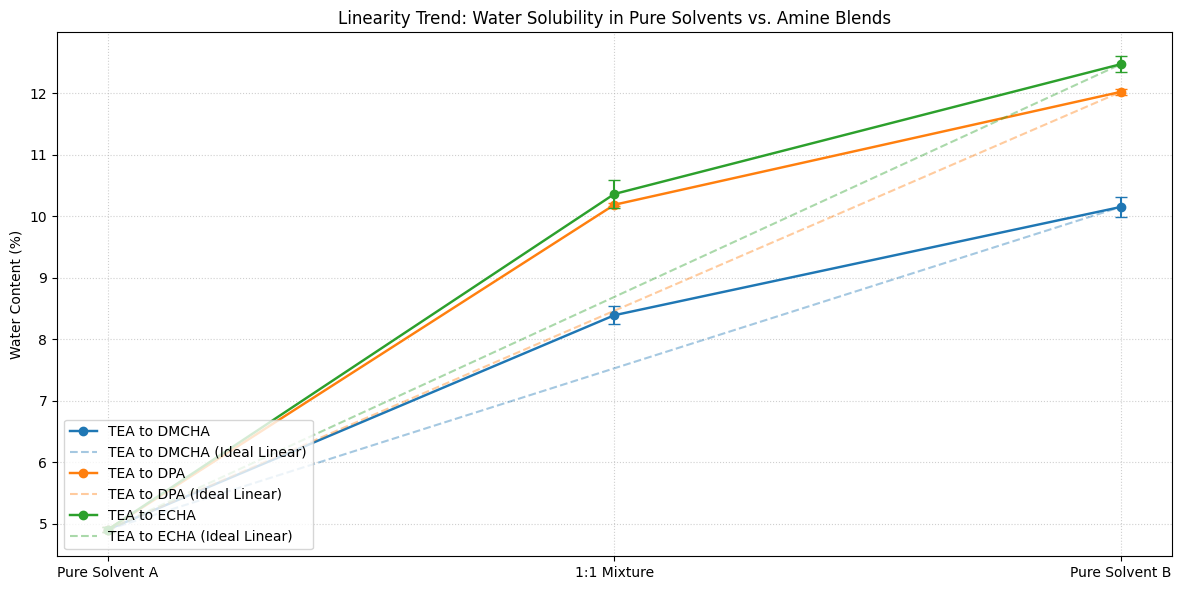

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Water % Data
water_data = {
    "Pure DMCHA": [10.31, 9.99],
    "Pure TEA": [4.95, 4.86],
    "Pure DPA": [12.07, 11.97],
    "Pure ECHA": [12.60, 12.34],
    "1:1 TEA:DMCHA": [8.5400, 8.2400],
    "1:1 TEA:DPA": [10.2100, 10.1600],
    "1:1 TEA:ECHA": [10.5800, 10.1400],
}

# Means and ranges
means = {k: np.mean(v) for k, v in water_data.items()}
mins = {k: np.min(v) for k, v in water_data.items()}
maxs = {k: np.max(v) for k, v in water_data.items()}

# Define the solvent pairings for the X-axis mapping
# Format: (Pure Solvent A, 1:1 Mixture, Pure Solvent B, Label)
pairings = [
     ("Pure TEA", "1:1 TEA:DMCHA", "Pure DMCHA", "TEA to DMCHA"),
    ("Pure TEA", "1:1 TEA:DPA", "Pure DPA", "TEA to DPA"),
    ("Pure TEA", "1:1 TEA:ECHA", "Pure ECHA", "TEA to ECHA"),
]

plt.figure(figsize=(12, 6))

# X-coordinates: 0 = Pure A, 0.5 = 1:1 mix, 1 = Pure B
x_coords = [0, 0.5, 1]

for pure_A, mix11, pure_B, label in pairings:
    y_vals = [means[pure_A], means[mix11], means[pure_B]]

    # Calculate lower and upper error bounds from the means
    y_err_lower = [
        means[pure_A] - mins[pure_A],
        means[mix11] - mins[mix11],
        means[pure_B] - mins[pure_B]
    ]
    y_err_upper = [
        maxs[pure_A] - means[pure_A],
        maxs[mix11] - means[mix11],
        maxs[pure_B] - means[pure_B]
    ]
    y_err = [y_err_lower, y_err_upper]

    # 1. Plot observed data with markers and solid lines
    line, = plt.plot(x_coords, y_vals, 'o-', label=label, markersize=6, linewidth=1.75)

    # 2. Add range error bars matching the line color
    plt.errorbar(x_coords, y_vals, yerr=y_err, fmt='none', ecolor=line.get_color(), capsize=4)

    # 3. Plot the "Ideal Linear" reference line (dashed line directly connecting endpoints)
    plt.plot([0, 1], [means[pure_A], means[pure_B]], '--', color=line.get_color(), alpha=0.4, label=f"{label} (Ideal Linear)")

# Formatting the plot
plt.xticks([0, 0.5, 1], ["Pure Solvent A", "1:1 Mixture", "Pure Solvent B"])
plt.ylabel("Water Content (%)")
plt.title("Linearity Trend: Water Solubility in Pure Solvents vs. Amine Blends")

plt.legend(loc="lower left")  # Lower left avoids overlapping the high water values on the right
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('water_trend_updated.png')
plt.show()